# DINOv3 image predictions and error analysis

This notebook loads a prediction run from the `fungitastic-binary-head` MLflow experiment and evaluates unique, labeled images from `data/dataset/deduplicated/manifest.csv`. The prediction artifact covers every raw image; evaluation joins only canonical images retained by deduplication. The validation fold is the holdout set; training metrics are included for comparison and are not an unbiased estimate.

By default, the notebook selects the prediction run whose associated training run finished most recently; if that training run has multiple predictions, it selects the most recently started prediction. Set `PREDICTION_RUN_ID` in the first code cell to pin a specific prediction run. The currently stored predictions were generated before this dataset and split refresh. Retrain and rerun prediction before interpreting validation metrics as a holdout estimate for these new splits.

The two saved sigmoid scores are independent. Exactly one score at or above 0.5 predicts `macroscopic` or `microscopic`; both below 0.5 predicts `not-mushroom`; both at or above 0.5 predicts `unknown`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix, precision_recall_curve,
    roc_auc_score, roc_curve,
)
from IPython.display import display
from mlflow import MlflowClient

WORKING_DIR = Path.cwd().resolve()
REPO_DIR = next((path for path in (WORKING_DIR, *WORKING_DIR.parents) if (path / "data/dataset/deduplicated/manifest.csv").is_file()), None)
if REPO_DIR is None:
    raise FileNotFoundError(f"Could not locate data/dataset/deduplicated/manifest.csv from {WORKING_DIR}")
PROJECT_DIR = next((path for path in (WORKING_DIR, *WORKING_DIR.parents) if (path / "scripts/prepare_dataset.py").is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(f"Could not locate scripts/prepare_dataset.py from {WORKING_DIR}")
DATA_DIR = REPO_DIR / "data"
CLEAN_MANIFEST_PATH = DATA_DIR / "dataset/deduplicated/manifest.csv"
MLFLOW_TRACKING_URI = f"sqlite:///{DATA_DIR / 'artifacts/mlflow/mlflow.db'}"
MLFLOW_EXPERIMENT_NAME = "fungitastic-binary-head"
PREDICTION_RUN_ID = None  # Set a run ID to pin a prediction; otherwise use the latest finished training run.
TRAIN_PATH = DATA_DIR / "dataset/splits/train.csv"
VAL_PATH = DATA_DIR / "dataset/splits/val.csv"

print(f"Project: {REPO_DIR}")
mlflow_client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
experiment = mlflow_client.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME)
if experiment is None:
    raise ValueError(f"MLflow experiment does not exist: {MLFLOW_EXPERIMENT_NAME}")
if PREDICTION_RUN_ID:
    prediction_run = mlflow_client.get_run(PREDICTION_RUN_ID)
    if prediction_run.info.experiment_id != experiment.experiment_id:
        raise ValueError(f"Prediction run {PREDICTION_RUN_ID} is not in {MLFLOW_EXPERIMENT_NAME!r}.")
else:
    candidate_runs = mlflow_client.search_runs(
        [experiment.experiment_id],
        filter_string="tags.run_type = 'prediction' and attributes.status = 'FINISHED'",
        order_by=["attributes.start_time DESC"],
        max_results=1000,
    )
    candidates_with_training = []
    for candidate in candidate_runs:
        parent_id = candidate.data.tags.get("mlflow.parentRunId")
        if not parent_id:
            continue
        try:
            parent_run = mlflow_client.get_run(parent_id)
        except Exception:
            continue
        if (
            parent_run.info.experiment_id != experiment.experiment_id
            or parent_run.info.status != "FINISHED"
            or parent_run.info.end_time is None
        ):
            continue
        candidates_with_training.append((
            parent_run.info.end_time,
            candidate.info.start_time,
            candidate,
        ))
    if not candidates_with_training:
        raise FileNotFoundError(
            f"No finished prediction runs with a finished training parent found in {MLFLOW_EXPERIMENT_NAME!r}."
        )
    # Prefer the latest completed training run; if it has multiple predictions,
    # use the most recently started prediction run for that training run.
    prediction_run = max(candidates_with_training, key=lambda item: (item[0], item[1], item[2].info.run_id))[2]
if prediction_run.info.status != "FINISHED" or prediction_run.data.tags.get("run_type") != "prediction":
    raise ValueError(f"MLflow run {prediction_run.info.run_id} is not a finished prediction run.")
training_run_id = prediction_run.data.tags.get("mlflow.parentRunId")
artifact_path = prediction_run.data.tags.get("prediction_artifact_path")
if not training_run_id or not artifact_path:
    raise ValueError(f"Prediction run {prediction_run.info.run_id} is missing its training run or artifact reference.")
training_run = mlflow_client.get_run(training_run_id)
if training_run.info.status != "FINISHED" or training_run.info.end_time is None:
    raise ValueError(f"Training parent {training_run_id} is not finished.")
if training_run.info.experiment_id != experiment.experiment_id:
    raise ValueError(f"Training parent {training_run_id} is not in {MLFLOW_EXPERIMENT_NAME!r}.")
predictions_path = Path(mlflow_client.download_artifacts(training_run_id, artifact_path))
training_finished_at = pd.to_datetime(training_run.info.end_time, unit="ms", utc=True)
print(f"MLflow prediction run: {prediction_run.info.run_id}")
print(f"Training run: {training_run_id}")
print(f"Training finished: {training_finished_at:%Y-%m-%d %H:%M:%S UTC}")
print(f"Prediction artifact: {artifact_path}")
print(f"Deduplicated manifest: {CLEAN_MANIFEST_PATH}")

Project: /home/simone/simone/find-fungi
MLflow prediction run: 2c19ee752f4f4a9ab921ccc201dd183c
Training run: e865c46c53f64ef6a9595f5c28caaea0
Training finished: 2026-10-07 18:45:30 UTC
Prediction artifact: predictions/2c19ee752f4f4a9ab921ccc201dd183c/predictions.csv
Deduplicated manifest: /home/simone/simone/find-fungi/data/dataset/deduplicated/manifest.csv


In [ ]:
predictions = pd.read_csv(
    predictions_path,
    dtype={"mushroom_id": "string", "image": "string", "predicted_label": "string"},
)
clean_manifest = pd.read_csv(
    CLEAN_MANIFEST_PATH,
    dtype={"mushroom_id": "string", "image": "string", "label": "string"},
)

# The clean manifest stores the canonical raw image path and one row per exact image.
clean_manifest["label"] = clean_manifest["label"].fillna("").str.strip()
labeled = clean_manifest.loc[clean_manifest["label"].ne("")].copy()
labeled["true_label"] = labeled["label"].map({"macroscopic": "macroscopic", "micro": "microscopic", "not-mushroom": "not-mushroom"})
if labeled["true_label"].isna().any():
    raise ValueError("The deduplicated manifest contains an unsupported label.")

predictions["mushroom_id"] = predictions["mushroom_id"].astype("string")
predictions["image"] = predictions["image"].astype("string").map(lambda value: Path(value).name)
predictions = predictions.drop(columns="image_path")  # Keep the canonical dataset path from the manifest.
for column in ("probability_macroscopic", "probability_micro"):
    predictions[column] = pd.to_numeric(predictions[column], errors="coerce")

annotated = labeled.merge(
    predictions,
    on=["mushroom_id", "image"],
    how="left",
    validate="one_to_one",
    indicator=True,
)
if not annotated["_merge"].eq("both").all():
    raise ValueError("Some deduplicated labeled images have no matching prediction row.")
annotated = annotated.drop(columns="_merge")

split_rows = []
for split_name, manifest_path in (("train", TRAIN_PATH), ("val", VAL_PATH)):
    split = pd.read_csv(manifest_path, dtype={"mushroom_id": "string", "image": "string"})
    split_rows.append(split[["mushroom_id", "image"]].assign(split=split_name))
splits = pd.concat(split_rows, ignore_index=True)
annotated = annotated.merge(
    splits,
    on=["mushroom_id", "image"],
    how="left",
    validate="one_to_one",
)
if annotated["split"].isna().any():
    raise ValueError("Some deduplicated labeled images do not belong to train or validation.")

annotated["correct"] = annotated["predicted_label"].eq(annotated["true_label"])
annotated["threshold_margin"] = np.minimum(
    (annotated["probability_macroscopic"] - 0.5).abs(),
    (annotated["probability_micro"] - 0.5).abs(),
)
print(f"Raw image predictions loaded: {len(predictions):,}")
print(f"Unique labeled images evaluated: {len(annotated):,}")
print(f"Duplicate images excluded from evaluation: {int(clean_manifest['duplicate_count'].sum()):,}")

## Prediction overview

The first chart shows the predicted label distribution over readable images. The probability map shades all readable predictions by predicted class: blue for macroscopic, red for microscopic, green for not-mushroom, and gray for unknown. Hexagon opacity and shade both increase with the shared log-scaled count. White-outlined circles are labeled examples colored by ground-truth class. Points below both thresholds predict `not-mushroom`; points above both predict `unknown`.

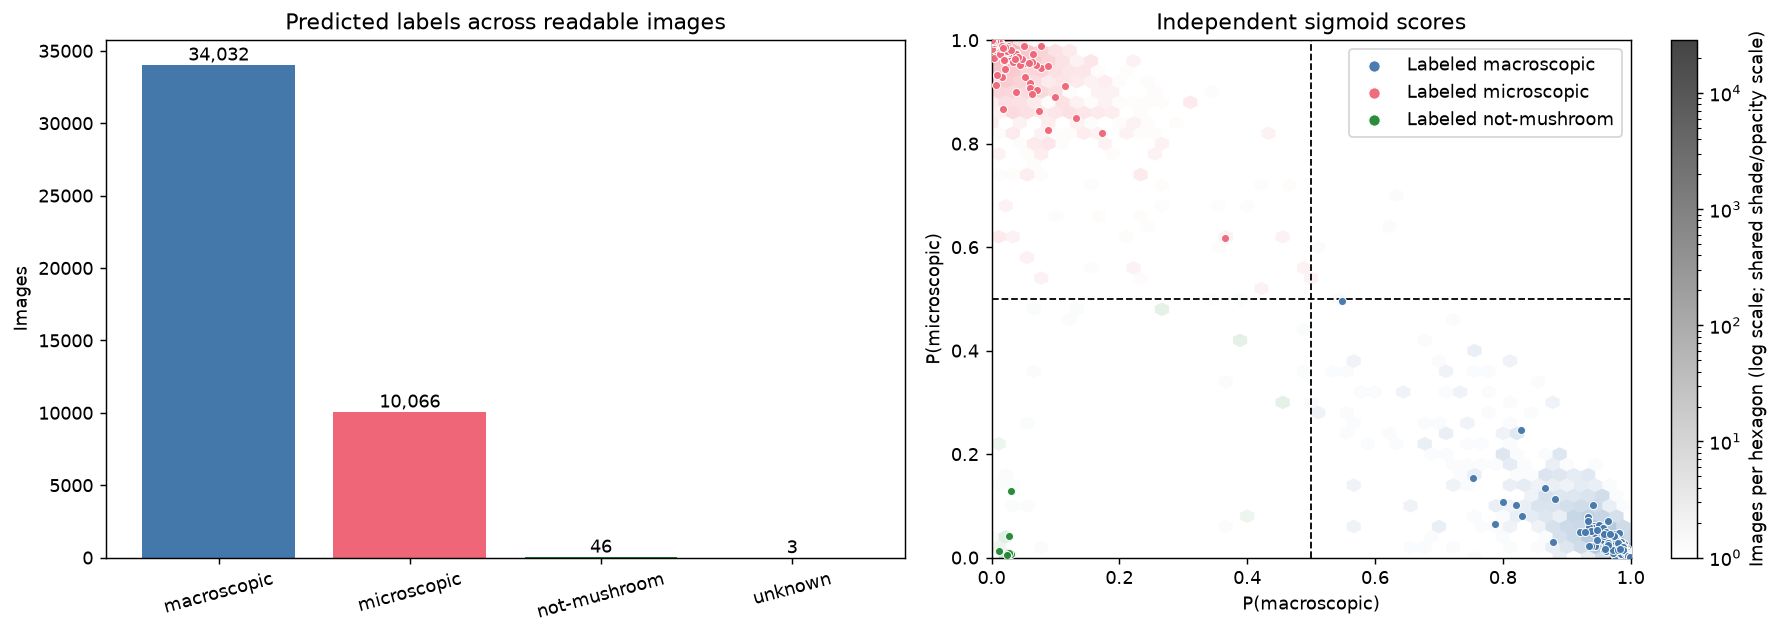

,images,share
predicted_label,,
macroscopic,34032,0.7709
microscopic,10066,0.228
not-mushroom,46,0.001
unknown,3,0.0001


Unreadable files: 2


In [4]:
readable = predictions.loc[predictions["error"].fillna("").eq("")].copy()
label_order = ["macroscopic", "microscopic", "not-mushroom", "unknown"]
label_counts = readable["predicted_label"].value_counts().reindex(label_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(label_counts.index, label_counts.values, color=["#4477AA", "#EE6677", "#228833", "#999999"])
axes[0].set_title("Predicted labels across readable images")
axes[0].set_ylabel("Images")
axes[0].tick_params(axis="x", rotation=15)
for x, y in enumerate(label_counts.values):
    axes[0].text(x, y, f"{y:,}", ha="center", va="bottom")

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, LogNorm, to_rgb

prediction_colors = {
    "macroscopic": "#4477AA",
    "microscopic": "#EE6677",
    "not-mushroom": "#228833",
    "unknown": "#777777",
}

def density_cmap(color):
    red, green, blue = to_rgb(color)
    return LinearSegmentedColormap.from_list(
        f"density_{color.replace('#', '')}",
        [(red, green, blue, 0.025), (red, green, blue, 0.88)],
    )

# Shade raw predictions by their predicted class; a shared log scale controls
# both color intensity and opacity so rare bins stay transparent.
density_hexes = []
for predicted_label, color in prediction_colors.items():
    group = readable.loc[readable["predicted_label"].eq(predicted_label)]
    if group.empty:
        continue
    density_hexes.append(axes[1].hexbin(
        group["probability_macroscopic"],
        group["probability_micro"],
        gridsize=45,
        extent=(0, 1, 0, 1),
        mincnt=1,
        cmap=density_cmap(color),
        linewidths=0,
        zorder=1,
    ))
max_hex_count = max(float(hexes.get_array().max()) for hexes in density_hexes)
density_norm = LogNorm(vmin=1, vmax=max(2, max_hex_count))
for hexes in density_hexes:
    hexes.set_norm(density_norm)

axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1)
colors = {"macroscopic": "#4477AA", "microscopic": "#EE6677", "not-mushroom": "#228833"}
for truth, group in annotated.groupby("true_label"):
    axes[1].scatter(
        group["probability_macroscopic"],
        group["probability_micro"],
        s=20,
        alpha=0.96,
        color=colors[truth],
        edgecolors="white",
        linewidths=0.55,
        label=f"Labeled {truth}",
        zorder=3,
    )
axes[1].set(xlim=(0, 1), ylim=(0, 1), xlabel="P(macroscopic)", ylabel="P(microscopic)")
axes[1].set_title("Independent sigmoid scores")
axes[1].legend(loc="upper right", markerscale=1.4)
count_mappable = ScalarMappable(
    norm=density_norm,
    cmap=LinearSegmentedColormap.from_list("density_count_key", ["white", "#444444"]),
)
count_mappable.set_array([])
fig.colorbar(
    count_mappable,
    ax=axes[1],
    label="Images per hexagon (log scale; shared shade/opacity scale)",
)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"images": label_counts, "share": (label_counts / len(readable)).round(4)}))
print(f"Unreadable files: {predictions['error'].fillna('').ne('').sum():,}")

## Error analysis by split

The tables use scikit-learn's `classification_report` for per-class precision, recall, F1, and support. Confusion matrices use rows for true labels and columns for predicted labels. All labeled metrics use one canonical row per exact image from the deduplicated manifest. The validation fold is the holdout result; training metrics are included for diagnosis.

`unknown` means both outputs crossed 0.5, so the two outputs conflict; it has no ground-truth support and is an error for the true class. `not-mushroom` is a ground-truth class trained as `[0, 0]`. `Coverage` is the fraction assigned one of the three non-ambiguous labels.

## Precision–recall curves

Curves are one-vs-rest for the three ground-truth labels and are shown separately for training and validation. The macroscopic and microscopic scores use their sigmoid outputs. The `not-mushroom` score is the probability of both outputs being negative, `(1 - P(macroscopic)) * (1 - P(microscopic))`, consistent with its `[0, 0]` training target. `unknown` has no ground-truth support, so it is not plotted as a target class. Average precision (AP) is shown in each legend; the dotted line is the class prevalence baseline.

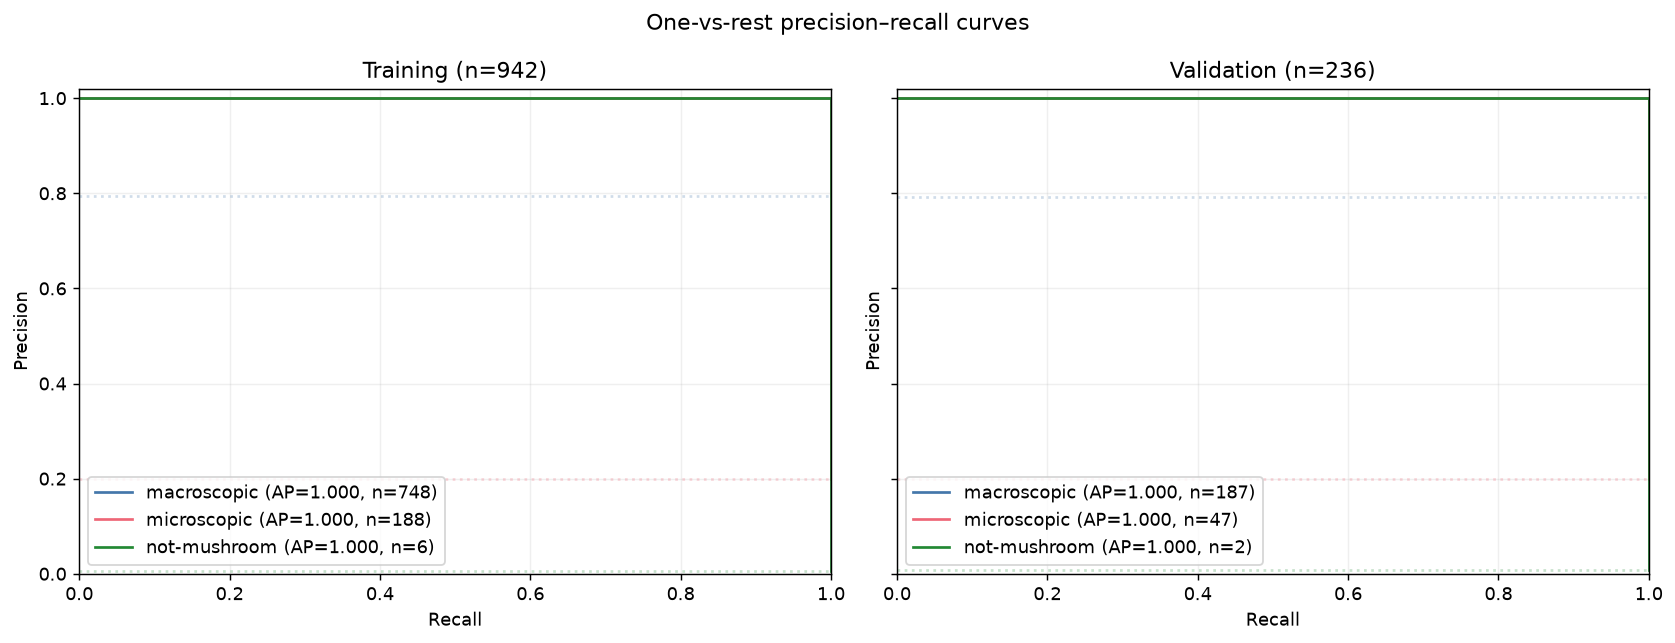

In [1]:
pr_classes = ["macroscopic", "microscopic", "not-mushroom"]
pr_colors = {"macroscopic": "#4477AA", "microscopic": "#EE6677", "not-mushroom": "#228833"}


def one_vs_rest_scores(frame):
    return {
        "macroscopic": frame["probability_macroscopic"].to_numpy(),
        "microscopic": frame["probability_micro"].to_numpy(),
        "not-mushroom": ((1 - frame["probability_macroscopic"]) * (1 - frame["probability_micro"])).to_numpy(),
    }


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (split_name, subset) in zip(
    axes,
    [("Training", annotated.loc[annotated["split"].eq("train")]), ("Validation", annotated.loc[annotated["split"].eq("val")])],
):
    scores = one_vs_rest_scores(subset)
    for label in pr_classes:
        truth = subset["true_label"].eq(label).to_numpy()
        if truth.sum() == 0 or truth.sum() == len(truth):
            print(f"Skipping {label} in {split_name}: need both positive and negative examples")
            continue
        precision, recall, _ = precision_recall_curve(truth, scores[label])
        average_precision = average_precision_score(truth, scores[label])
        ax.plot(recall, precision, color=pr_colors[label], label=f"{label} (AP={average_precision:.3f}, n={int(truth.sum())})")
        ax.axhline(truth.mean(), color=pr_colors[label], linestyle=":", alpha=0.25)
    ax.set(title=f"{split_name} (n={len(subset)})", xlim=(0, 1), ylim=(0, 1.02), xlabel="Recall", ylabel="Precision")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower left")
fig.suptitle("One-vs-rest precision–recall curves")
plt.tight_layout()
plt.show()


## ROC curves

These one-vs-rest ROC curves use the same class scores as the precision–recall plots and show training and validation separately. The legend reports ROC AUC. The diagonal is chance ranking. `Unknown` is omitted because it is an ambiguous prediction outcome, not a ground-truth class.

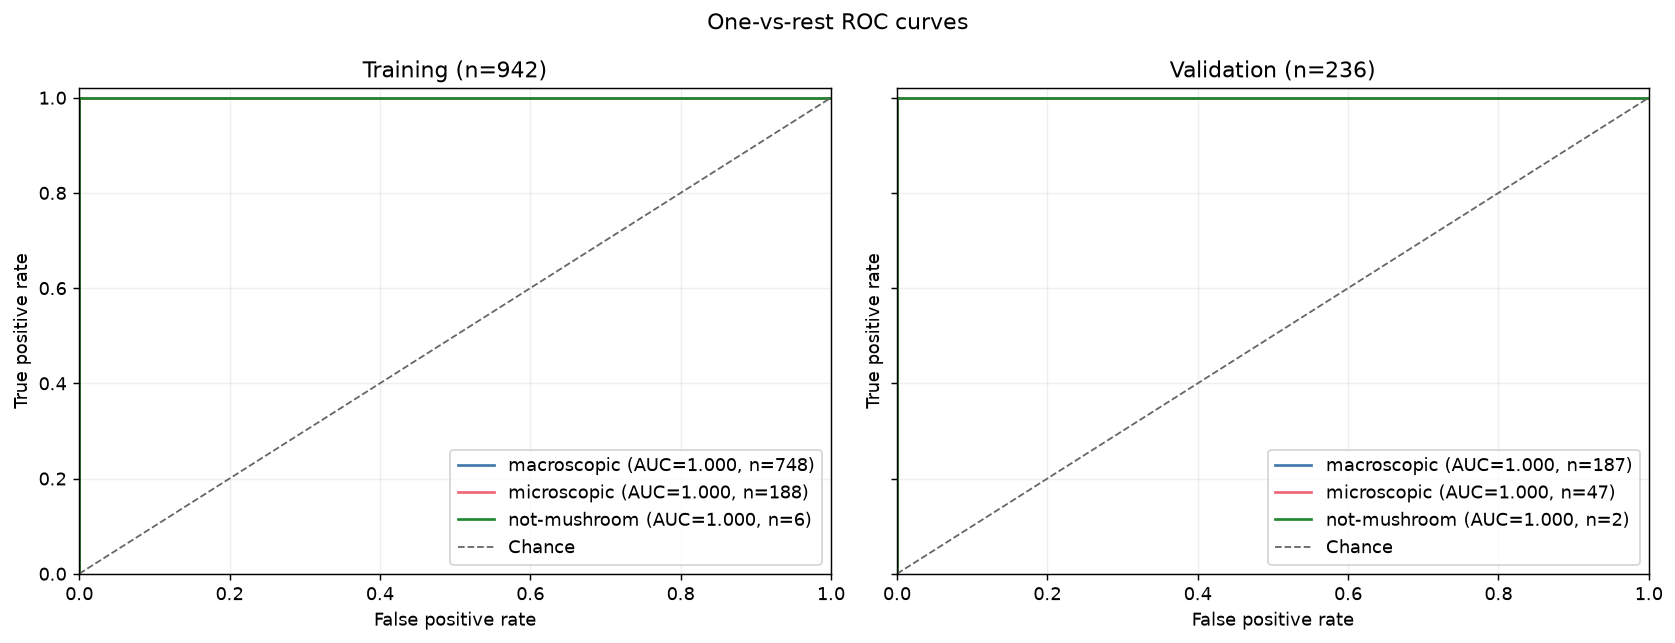

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (split_name, subset) in zip(
    axes,
    [("Training", annotated.loc[annotated["split"].eq("train")]), ("Validation", annotated.loc[annotated["split"].eq("val")])],
):
    scores = one_vs_rest_scores(subset)
    for label in pr_classes:
        truth = subset["true_label"].eq(label).to_numpy()
        if truth.sum() == 0 or truth.sum() == len(truth):
            print(f"Skipping {label} in {split_name}: need both positive and negative examples")
            continue
        false_positive_rate, true_positive_rate, _ = roc_curve(truth, scores[label])
        area = roc_auc_score(truth, scores[label])
        ax.plot(false_positive_rate, true_positive_rate, color=pr_colors[label], label=f"{label} (AUC={area:.3f}, n={int(truth.sum())})")
    ax.plot([0, 1], [0, 1], color="#666666", linestyle="--", linewidth=1, label="Chance")
    ax.set(title=f"{split_name} (n={len(subset)})", xlim=(0, 1), ylim=(0, 1.02), xlabel="False positive rate", ylabel="True positive rate")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower right")
fig.suptitle("One-vs-rest ROC curves")
plt.tight_layout()
plt.show()


## DINOv3 pooled embeddings after the selected fine-tuning configuration

Each validation image is represented by its pooled 384-dimensional DINOv3 backbone embedding after loading the trained checkpoint. If `--train-last-layer` was used, this includes the tuned final transformer block; otherwise the backbone remains frozen. PCA shows how the image-level embeddings spread across true classes. The two lines are the trained head’s independent 0.5 probability boundaries projected onto the PCA plane; light shading shows its four multilabel outcomes. The stars and crosses mark the best and worst scored images per class. The head-only option leaves backbone features unchanged; the optional last-layer setting changes the final-block features.


`R` in the legend reports how much of each head weight direction lies in the two plotted PCA axes. The boundaries are exact for points on that plane; actual image logits also depend on omitted PCA dimensions.


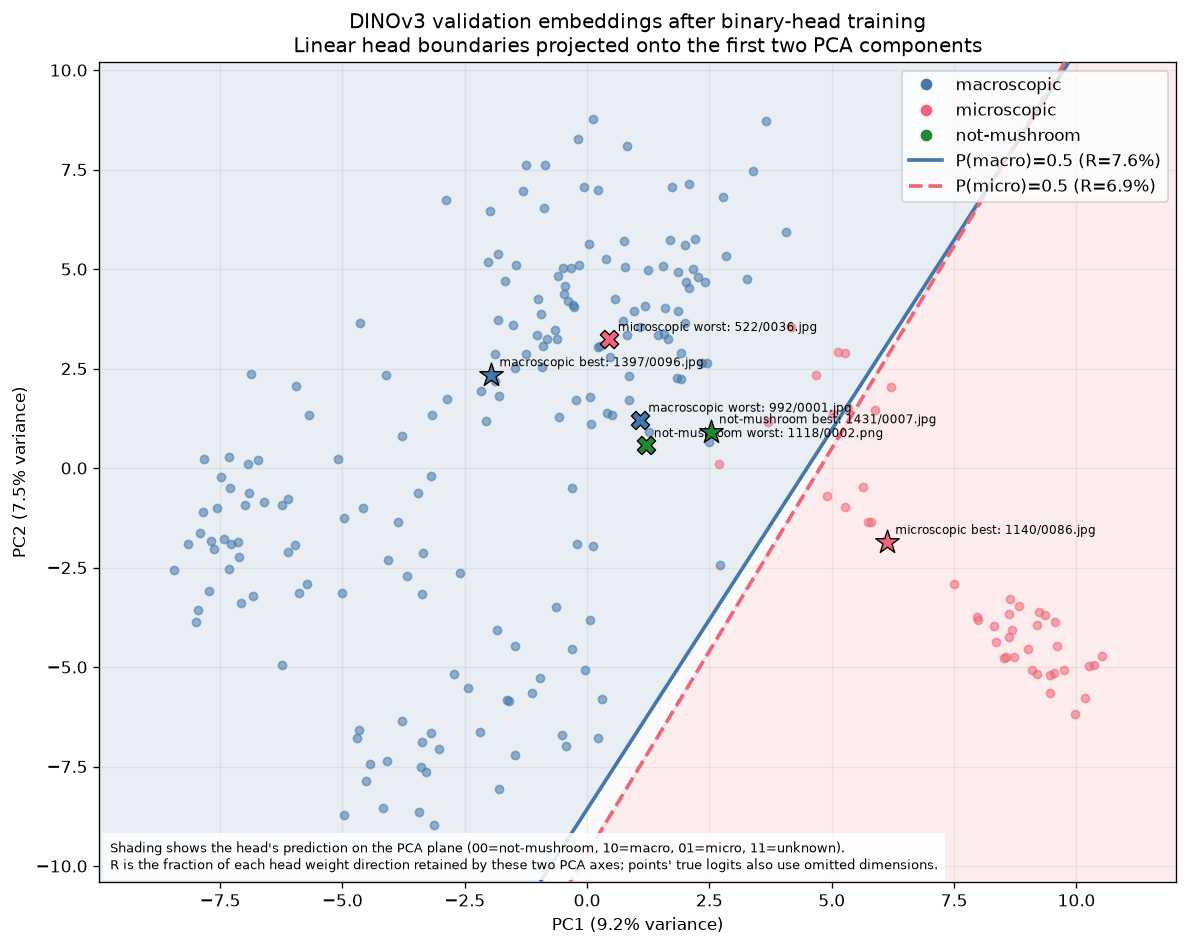

true_label,rank,mushroom_id,image,predicted_label,class_score
macroscopic,best,1397,0096.jpg,macroscopic,0.999976
macroscopic,worst,992,0001.jpg,macroscopic,0.753467
microscopic,best,1140,0086.jpg,microscopic,0.999877
microscopic,worst,522,0036.jpg,microscopic,0.890294
not-mushroom,best,1431,0007.jpg,not-mushroom,0.963493
not-mushroom,worst,1118,0002.png,not-mushroom,0.931691


DINO feature output rendered on cuda


In [11]:
import timm
import torch
from huggingface_hub import hf_hub_download
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import sys

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
from scripts.image_dataset import ImagePathDataset


validation_features = annotated.loc[annotated["split"].eq("val")].reset_index(drop=True).copy()
validation_features["score_not-mushroom"] = (
    (1 - validation_features["probability_macroscopic"])
    * (1 - validation_features["probability_micro"])
)
feature_classes = ["macroscopic", "microscopic", "not-mushroom"]
feature_score_columns = {
    "macroscopic": "probability_macroscopic",
    "microscopic": "probability_micro",
    "not-mushroom": "score_not-mushroom",
}
feature_colors = {"macroscopic": "#4477AA", "microscopic": "#EE6677", "not-mushroom": "#228833"}

selected_feature_images = []
for label in feature_classes:
    class_rows = validation_features.loc[validation_features["true_label"].eq(label)]
    if class_rows.empty:
        print(f"Skipping {label}: no validation images")
        continue
    score_column = feature_score_columns[label]
    best_index = int(class_rows[score_column].idxmax())
    worst_index = int(class_rows[score_column].idxmin())
    if best_index == worst_index:
        selected_feature_images.append({"feature_index": best_index, "true_label": label, "rank": "best and worst"})
    else:
        selected_feature_images.extend([
            {"feature_index": best_index, "true_label": label, "rank": "best"},
            {"feature_index": worst_index, "true_label": label, "rank": "worst"},
        ])
selected_feature_images = pd.DataFrame(selected_feature_images)

head_checkpoint_path = Path(
    mlflow_client.download_artifacts(training_run_id, "checkpoint/best_binary_head.pt")
)
head_checkpoint = torch.load(head_checkpoint_path, map_location="cpu", weights_only=True)
if head_checkpoint.get("model_id") != "paulbauriegel/fungitastic-dinov3-vits16-384":
    raise ValueError("The selected training run contains a different base model.")
base_checkpoint_path = hf_hub_download(
    repo_id=head_checkpoint["model_id"],
    filename="best.pt",
    revision=head_checkpoint["model_revision"],
)
base_checkpoint = torch.load(base_checkpoint_path, map_location="cpu", weights_only=False)
feature_model = timm.create_model(
    base_checkpoint["model_name"],
    pretrained=False,
    num_classes=int(base_checkpoint["num_classes"]),
    img_size=int(base_checkpoint["img_size"]),
)
feature_model.load_state_dict(base_checkpoint["model_state"], strict=True)
feature_model.reset_classifier(num_classes=2)
feature_model.get_classifier().load_state_dict(head_checkpoint["classifier_state_dict"], strict=True)
last_transformer_block_state = head_checkpoint.get("last_transformer_block_state_dict")
if last_transformer_block_state is not None:
    blocks = getattr(feature_model, "blocks", None)
    if blocks is None or len(blocks) == 0:
        raise TypeError("Checkpoint contains a tuned final block, but this model exposes no model.blocks.")
    blocks[-1].load_state_dict(last_transformer_block_state, strict=True)
feature_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_model.to(feature_device).eval()
data_config = head_checkpoint.get("data_config") or timm.data.resolve_model_data_config(feature_model)
feature_transform = timm.data.create_transform(**data_config, is_training=False)
feature_dataset = ImagePathDataset(
    [PROJECT_DIR / image_path for image_path in validation_features["image_path"]],
    feature_transform,
)
feature_loader = DataLoader(
    feature_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=8,
    pin_memory=feature_device.type == "cuda",
    persistent_workers=True,
)


def extract_backbone_embeddings(model):
    batches = []
    with torch.inference_mode():
        for images in tqdm(feature_loader, desc="Extracting DINO embeddings", unit="batch"):
            images = images.to(feature_device, non_blocking=True)
            tokens = model.forward_features(images)
            embeddings = model.forward_head(tokens, pre_logits=True)
            batches.append(embeddings.float().cpu().numpy())
    return np.concatenate(batches, axis=0)


features_after_training = extract_backbone_embeddings(feature_model)
feature_pca = PCA(n_components=2, random_state=42)
features_after_2d = feature_pca.fit_transform(features_after_training)

# The trained head emits independent macro and micro logits. Project each
# hyperplane onto the same 2D PCA plane used for this scatter plot.
classifier = feature_model.get_classifier()
head_weights = classifier.weight.detach().float().cpu().numpy()
head_bias = classifier.bias.detach().float().cpu().numpy()
pca_head_weights = head_weights @ feature_pca.components_.T
pca_head_bias = head_weights @ feature_pca.mean_ + head_bias
pca_direction_coverage = (
    np.sum(pca_head_weights**2, axis=1) / np.sum(head_weights**2, axis=1)
)

pc1_limits = (features_after_2d[:, 0].min(), features_after_2d[:, 0].max())
pc2_limits = (features_after_2d[:, 1].min(), features_after_2d[:, 1].max())
pc1_pad = max((pc1_limits[1] - pc1_limits[0]) * 0.08, 1e-6)
pc2_pad = max((pc2_limits[1] - pc2_limits[0]) * 0.08, 1e-6)
pc1_values = np.linspace(pc1_limits[0] - pc1_pad, pc1_limits[1] + pc1_pad, 300)
pc2_values = np.linspace(pc2_limits[0] - pc2_pad, pc2_limits[1] + pc2_pad, 300)
xx, yy = np.meshgrid(pc1_values, pc2_values)
plane_logits = np.stack([
    pca_head_weights[j, 0] * xx + pca_head_weights[j, 1] * yy + pca_head_bias[j]
    for j in range(2)
])
macro_on = plane_logits[0] >= 0
micro_on = plane_logits[1] >= 0
# multilabel outputs map to the project labels: 00=not-mushroom, 10=macro,
# 01=micro, and 11=unknown (both output probabilities exceed 0.5).
plane_region = macro_on.astype(np.int8) + 2 * micro_on.astype(np.int8)

from matplotlib.lines import Line2D

region_colors = ["#d9d9d9", "#4477AA", "#EE6677", "#aa66aa"]
fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(
    xx, yy, plane_region,
    levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
    colors=region_colors, alpha=0.12, zorder=0,
)
for label in feature_classes:
    mask = validation_features["true_label"].eq(label).to_numpy()
    ax.scatter(
        features_after_2d[mask, 0], features_after_2d[mask, 1],
        s=24, alpha=0.55, color=feature_colors[label], label=label, zorder=2,
    )
for j, (output_label, color, linestyle) in enumerate([
    ("P(macro)=0.5", feature_colors["macroscopic"], "-"),
    ("P(micro)=0.5", feature_colors["microscopic"], "--"),
]):
    ax.contour(
        xx, yy, plane_logits[j], levels=[0], colors=[color],
        linewidths=2.2, linestyles=[linestyle], zorder=3,
    )
for _, selected in selected_feature_images.iterrows():
    index = int(selected["feature_index"])
    label = str(selected["true_label"])
    rank = str(selected["rank"])
    marker = "*" if rank == "best" else "X"
    ax.scatter(
        features_after_2d[index, 0], features_after_2d[index, 1],
        s=220 if marker == "*" else 120, marker=marker,
        color=feature_colors[label], edgecolors="black", linewidths=0.8, zorder=5,
    )
    row = validation_features.iloc[index]
    ax.annotate(
        f"{label} {rank}: {row['mushroom_id']}/{row['image']}",
        (features_after_2d[index, 0], features_after_2d[index, 1]),
        xytext=(5, 5), textcoords="offset points", fontsize=7,
    )
legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=feature_colors[label], label=label)
    for label in feature_classes
]
legend_handles.extend([
    Line2D([0], [0], color=feature_colors["macroscopic"], lw=2.2, linestyle="-",
           label=f"P(macro)=0.5 (R={pca_direction_coverage[0]:.1%})"),
    Line2D([0], [0], color=feature_colors["microscopic"], lw=2.2, linestyle="--",
           label=f"P(micro)=0.5 (R={pca_direction_coverage[1]:.1%})"),
])
ax.set_title(
    "DINOv3 validation embeddings after selected fine-tuning configuration\n"
    "Linear head boundaries projected onto the first two PCA components"
)
ax.set_xlabel(f"PC1 ({feature_pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({feature_pca.explained_variance_ratio_[1]:.1%} variance)")
ax.text(
    0.01, 0.01,
    "Shading shows the head's prediction on the PCA plane (00=not-mushroom, 10=macro, 01=micro, 11=unknown).\n"
    "R is the fraction of each head weight direction retained by these two PCA axes; points' true logits also use omitted dimensions.",
    transform=ax.transAxes, ha="left", va="bottom", fontsize=8,
    bbox={"facecolor": "white", "alpha": 0.86, "edgecolor": "none"},
)
ax.grid(alpha=0.2)
ax.legend(handles=legend_handles, loc="best")
plt.tight_layout()
plt.show()

selected_feature_table = selected_feature_images.merge(
    validation_features.reset_index(names="feature_index"),
    on=["feature_index", "true_label"],
    how="left",
)
selected_feature_table["class_score"] = [
    row[feature_score_columns[row["true_label"]]] for _, row in selected_feature_table.iterrows()
]
display(selected_feature_table[["true_label", "rank", "mushroom_id", "image", "predicted_label", "class_score"]].sort_values(["true_label", "rank"]))
print(f"Pooled embedding matrix after training: {features_after_training.shape}")


### Spatial patch-token feature grids

These grids show the final-layer DINOv3 patch-token features after the selected fine-tuning configuration for the five best and five worst validation images per true class, ranked by that class's score. Each image's spatial patch features (the grid size follows the model input resolution) are projected to RGB with its own PCA basis, following the DINOv3 feature-visualization approach. Colors are therefore meaningful within an image, not comparable between images. These are feature visualizations, not segmentation masks: the classifier was trained with image-level labels and has no patch-level mask supervision or decoder.


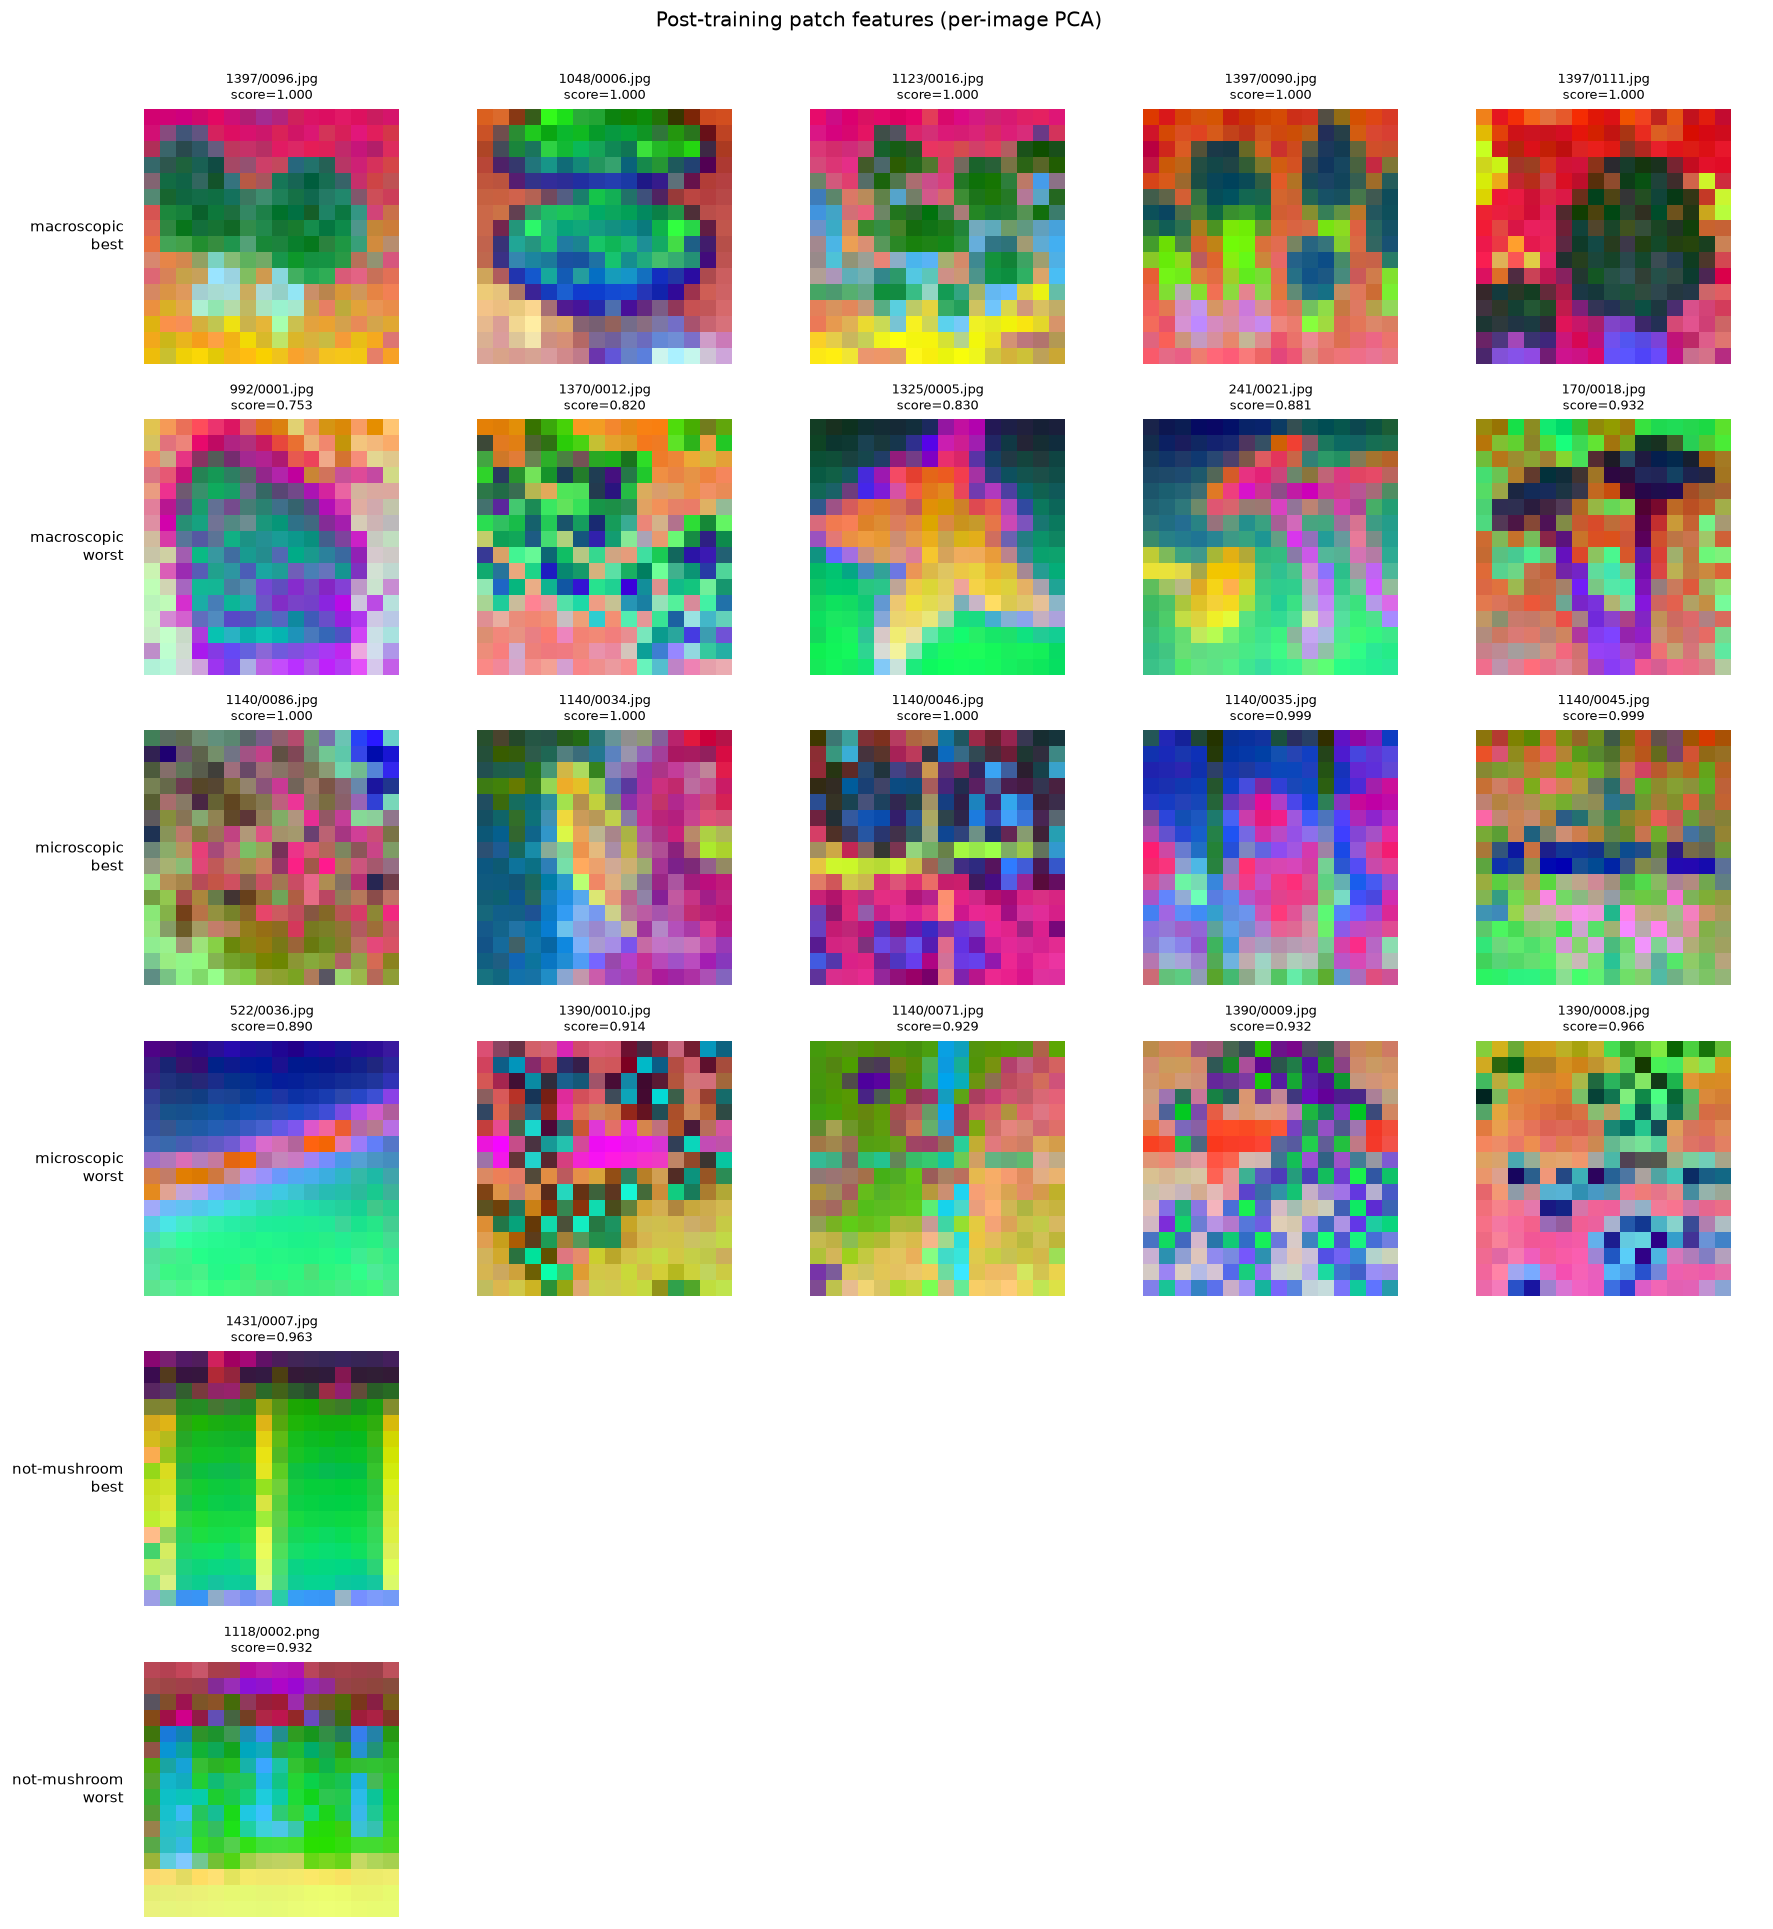

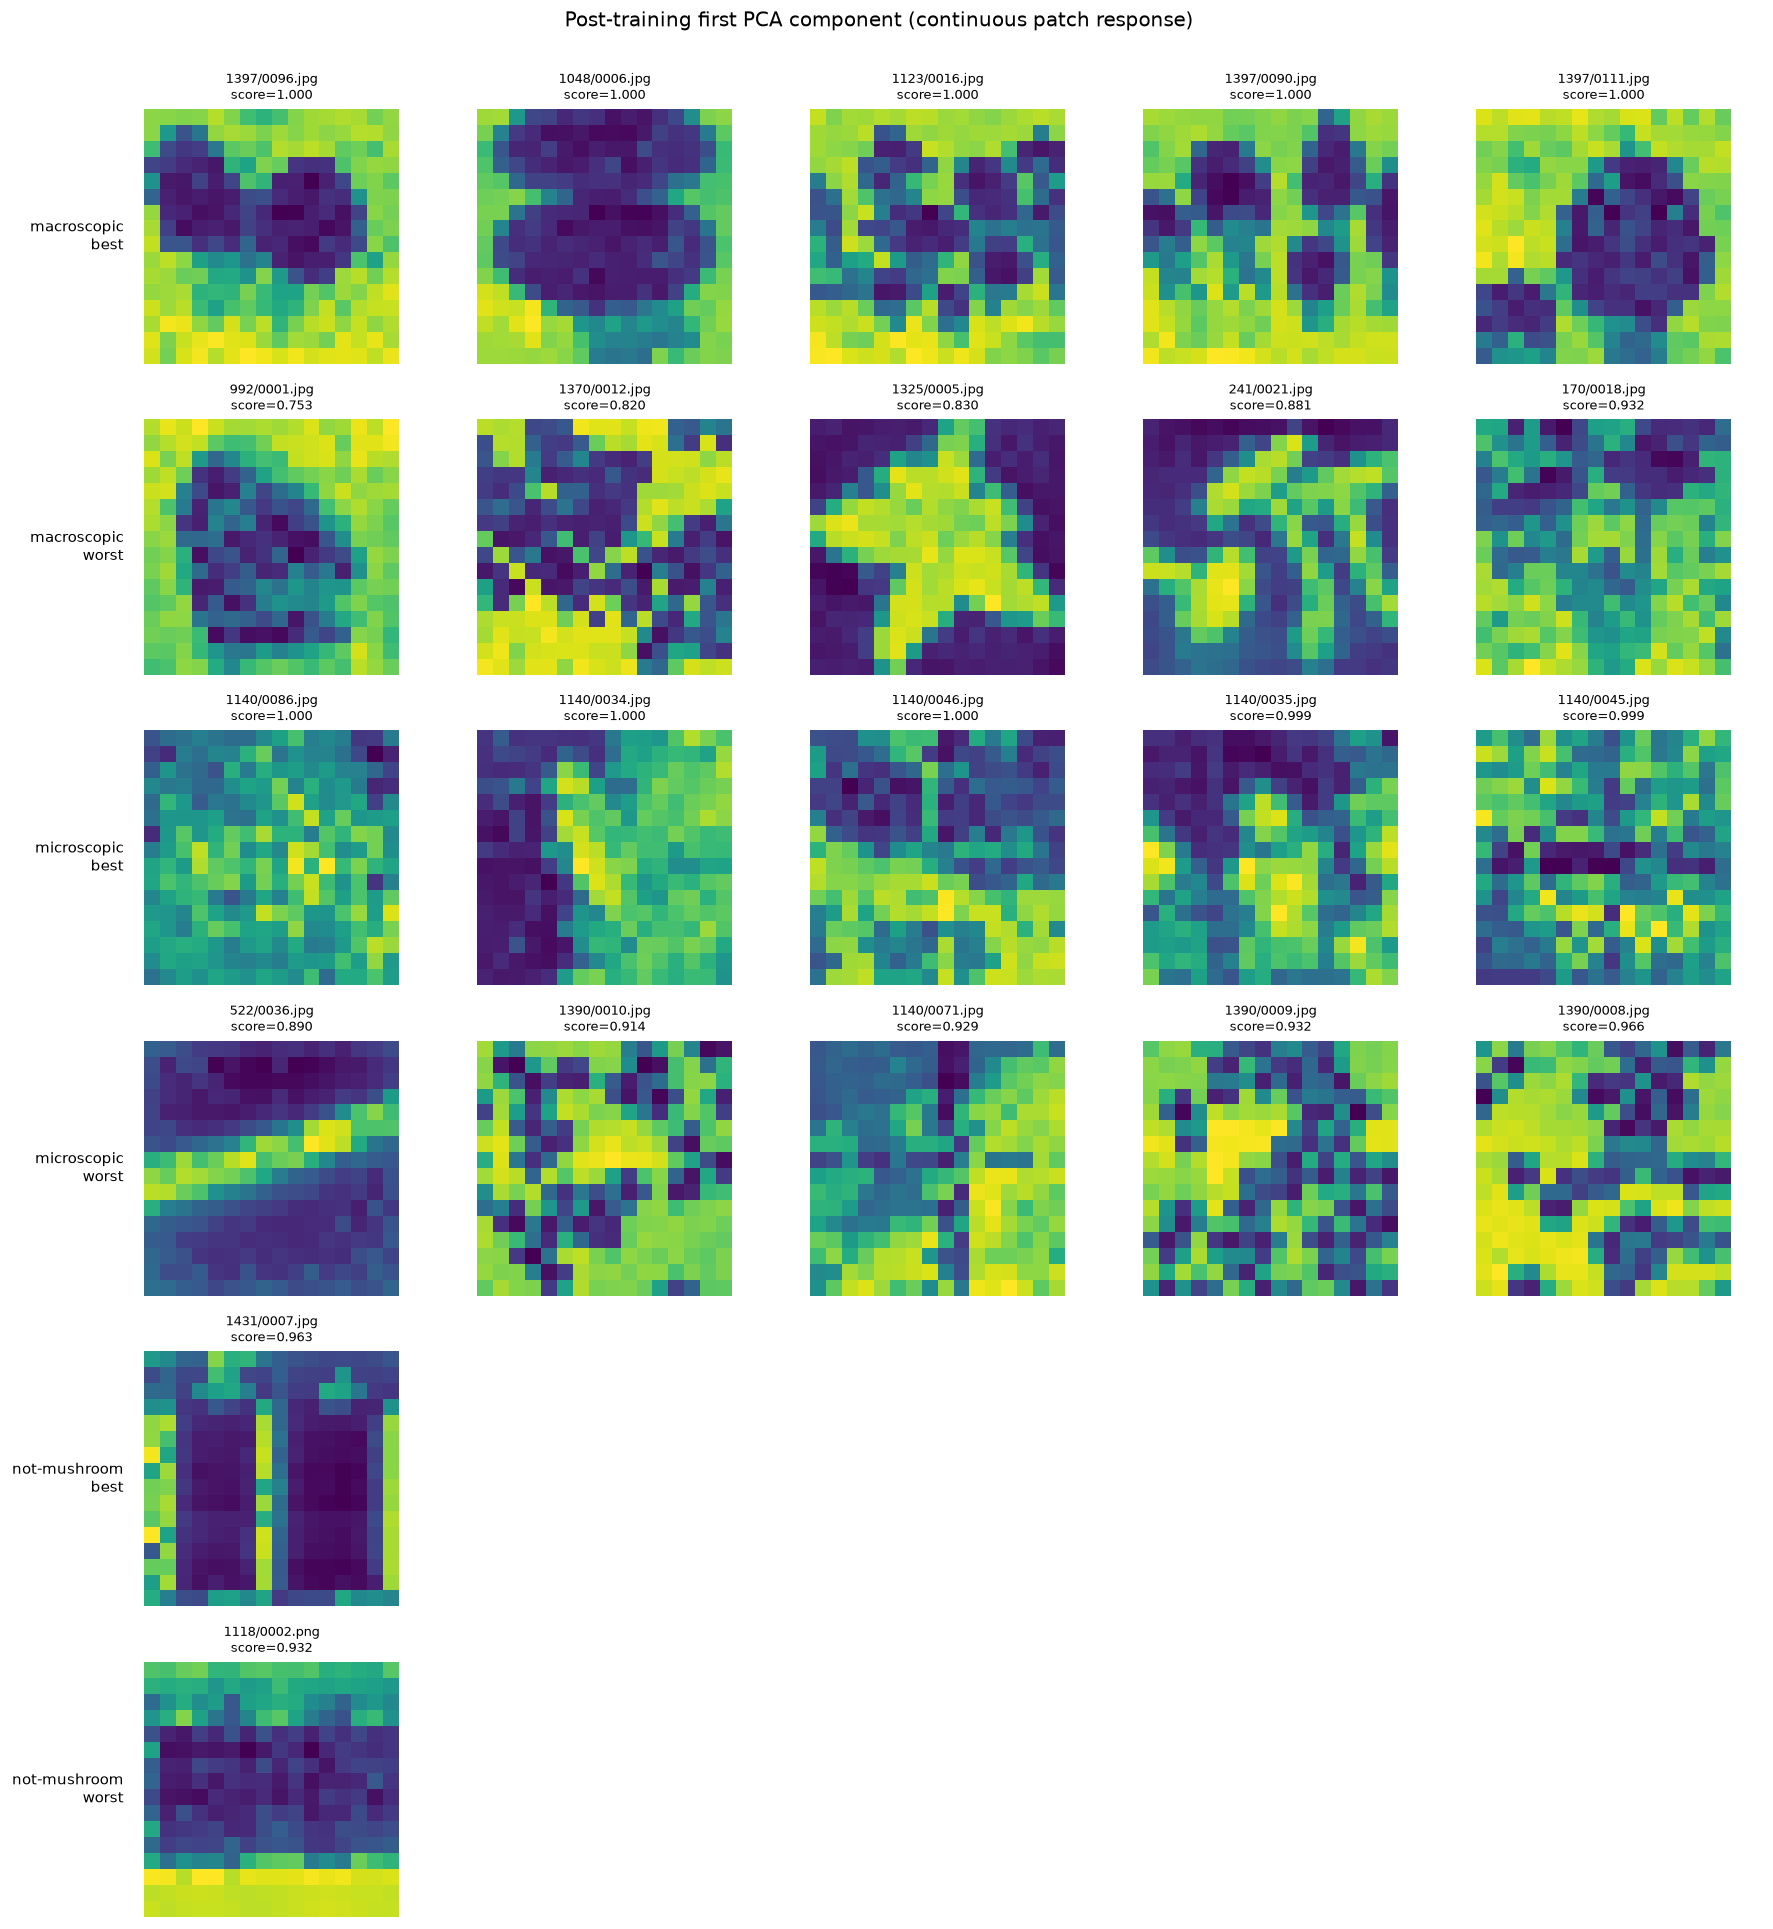

true_label,rank,mushroom_id,image,class_score
macroscopic,best,1397,0096.jpg,0.999976
macroscopic,best,1048,0006.jpg,0.999960
macroscopic,best,1123,0016.jpg,0.999949
macroscopic,best,1397,0090.jpg,0.999942
macroscopic,best,1397,0111.jpg,0.999942
macroscopic,worst,992,0001.jpg,0.753467
macroscopic,worst,1370,0012.jpg,0.819893
macroscopic,worst,1325,0005.jpg,0.830044
macroscopic,worst,241,0021.jpg,0.880797
macroscopic,worst,170,0018.jpg,0.932453


DINO feature output rendered on cuda


In [13]:
feature_grid_n = 5
feature_grid_rows = []
for label in feature_classes:
    class_rows = validation_features.loc[validation_features["true_label"].eq(label)]
    if class_rows.empty:
        continue
    score_column = feature_score_columns[label]
    n_per_rank = min(feature_grid_n, max(1, len(class_rows) // 2))
    for rank, ranked_rows in (
        ("best", class_rows.nlargest(n_per_rank, score_column)),
        ("worst", class_rows.nsmallest(n_per_rank, score_column)),
    ):
        for feature_index, row in ranked_rows.iterrows():
            feature_grid_rows.append({
                "feature_index": int(feature_index),
                "true_label": label,
                "rank": rank,
                "class_score": float(row[score_column]),
                "mushroom_id": row["mushroom_id"],
                "image": row["image"],
                "image_path": row["image_path"],
            })
feature_grid_rows = pd.DataFrame(feature_grid_rows)
feature_grid_dataset = ImagePathDataset(
    [PROJECT_DIR / image_path for image_path in feature_grid_rows["image_path"]],
    feature_transform,
)
feature_grid_loader = DataLoader(
    feature_grid_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=8,
    pin_memory=feature_device.type == "cuda",
    persistent_workers=True,
)
patch_size = feature_model.patch_embed.patch_size
if isinstance(patch_size, int):
    patch_height = patch_width = patch_size
else:
    patch_height, patch_width = patch_size
input_height, input_width = data_config["input_size"][1:]
patch_grid = (input_height // patch_height, input_width // patch_width)
prefix_tokens = int(feature_model.num_prefix_tokens)


def extract_patch_tokens(model):
    batches = []
    with torch.inference_mode():
        for images in tqdm(feature_grid_loader, desc="Extracting post-training patch features", unit="batch"):
            tokens = model.forward_features(images.to(feature_device, non_blocking=True))
            patches = tokens[:, prefix_tokens:, :]
            if patches.shape[1] != patch_grid[0] * patch_grid[1]:
                raise ValueError(
                    f"Expected {patch_grid[0] * patch_grid[1]} patch tokens after {prefix_tokens} prefix tokens; "
                    f"received {patches.shape[1]}"
                )
            batches.append(patches.float().cpu().numpy())
    return np.concatenate(batches, axis=0)


patch_tokens_after_training = extract_patch_tokens(feature_model)
patch_rgb_after = []
patch_pc1_after = []
for patch_tokens in patch_tokens_after_training:
    # Fit PCA within each image so the map retains its spatial feature structure.
    image_pca = PCA(n_components=3, whiten=True, random_state=42)
    image_pca_rgb = image_pca.fit_transform(patch_tokens)
    image_pca_rgb = image_pca_rgb.reshape(*patch_grid, 3)
    image_min = image_pca_rgb.min(axis=(0, 1), keepdims=True)
    image_max = image_pca_rgb.max(axis=(0, 1), keepdims=True)
    image_rgb = (image_pca_rgb - image_min) / np.maximum(image_max - image_min, 1e-8)
    patch_rgb_after.append(np.clip(image_rgb, 0, 1))

    first_component = image_pca_rgb[..., 0]
    component_min, component_max = first_component.min(), first_component.max()
    patch_pc1_after.append((first_component - component_min) / max(component_max - component_min, 1e-8))
patch_rgb_after = np.stack(patch_rgb_after)
patch_pc1_after = np.stack(patch_pc1_after)

image_mean = torch.tensor(data_config["mean"], dtype=torch.float32).view(3, 1, 1)
image_std = torch.tensor(data_config["std"], dtype=torch.float32).view(3, 1, 1)
feature_grid_source_images = []
for image_index in range(len(feature_grid_dataset)):
    normalized_image = feature_grid_dataset[image_index].float()
    source_rgb = (normalized_image * image_std + image_mean).clamp(0, 1).permute(1, 2, 0).numpy()
    feature_grid_source_images.append(source_rgb)

feature_grid_order = [(label, rank) for label in feature_classes for rank in ("best", "worst")]
feature_grid_figures = []
for feature_maps, panel_title, color_map in (
    (patch_rgb_after, "Post-training patch features (per-image PCA)", None),
    (patch_pc1_after, "Post-training first PCA component (continuous patch response)", "viridis"),
):
    fig, axes = plt.subplots(len(feature_grid_order), feature_grid_n, figsize=(15, 16), squeeze=False)
    for row_index, (label, rank) in enumerate(feature_grid_order):
        feature_grid_map_indices = feature_grid_rows.index[
            feature_grid_rows["true_label"].eq(label) & feature_grid_rows["rank"].eq(rank)
        ].to_numpy()
        row_examples = feature_grid_rows.loc[feature_grid_map_indices].reset_index(drop=True)
        for column_index, ax in enumerate(axes[row_index]):
            ax.axis("off")
            if column_index >= len(row_examples):
                continue
            example = row_examples.iloc[column_index]
            feature_map = feature_maps[int(feature_grid_map_indices[column_index])]
            ax.imshow(feature_map, cmap=color_map, interpolation="nearest")
            ax.set_title(
                f"{example['mushroom_id']}/{example['image']}\nscore={example['class_score']:.3f}",
                fontsize=8,
            )
        axes[row_index, 0].text(
            -0.08, 0.5, f"{label}\n{rank}", transform=axes[row_index, 0].transAxes,
            ha="right", va="center", fontsize=9,
        )
    fig.suptitle(panel_title, y=1.002)
    plt.tight_layout()
    plt.show()
    feature_grid_figures.append(fig)

display(feature_grid_rows[["true_label", "rank", "mushroom_id", "image", "class_score"]])
print(
    f"Post-training patch tokens: {patch_tokens_after_training.shape}; "
    f"patch grid={patch_grid}; PCA fitted independently for each image"
)


In [ ]:
def summarize(frame):
    classified = frame["predicted_label"].isin(("macroscopic", "microscopic", "not-mushroom"))
    return pd.Series({
        "images": len(frame),
        "correct": int(frame["correct"].sum()),
        "errors_including_unknown": int((~frame["correct"]).sum()),
        "unknown": int(frame["predicted_label"].eq("unknown").sum()),
        "coverage": classified.mean(),
        "accuracy_when_classified": frame.loc[classified, "correct"].mean(),
        "overall_accuracy": frame["correct"].mean(),
    })

split_summary = pd.DataFrame({
    split_name: summarize(group)
    for split_name, group in [("all labeled", annotated), *annotated.groupby("split", dropna=False)]
}).T

display(split_summary.style.format({
    "coverage": "{:.3%}",
    "accuracy_when_classified": "{:.3%}",
    "overall_accuracy": "{:.3%}",
}))

class_order = ["macroscopic", "microscopic", "not-mushroom", "unknown"]
report_columns = ["precision", "recall", "f1-score", "support"]
for split_name, subset in [("all labeled", annotated), *annotated.groupby("split")]:
    report = classification_report(
        subset["true_label"],
        subset["predicted_label"],
        labels=class_order,
        target_names=class_order,
        output_dict=True,
        zero_division=0,
    )
    per_class = pd.DataFrame(report).T.loc[class_order, report_columns]
    print(f"{split_name} per-class precision, recall, and F1")
    display(per_class)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (split_name, subset) in zip(
    axes,
    [("All labeled", annotated), ("Validation", annotated.loc[annotated["split"].eq("val")]),
     ("Training", annotated.loc[annotated["split"].eq("train")])],
):
    matrix = confusion_matrix(
        subset["true_label"], subset["predicted_label"], labels=class_order
    )
    ax.imshow(matrix, cmap="Blues")
    ax.set_title(f"{split_name} (n={len(subset)})")
    ax.set_xticks(range(len(class_order)), class_order, rotation=30, ha="right")
    ax.set_yticks(range(len(class_order)), class_order)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    for row in range(len(class_order)):
        for col in range(len(class_order)):
            ax.text(col, row, str(matrix[row, col]), ha="center", va="center")
fig.suptitle("Confusion matrices: true labels by predicted labels")
plt.tight_layout()
plt.show()

errors = annotated.loc[~annotated["correct"]].sort_values(["split", "threshold_margin"])
print(f"Labeled errors, including unknown predictions: {len(errors)}")
display(errors[[
    "split", "mushroom_id", "image", "true_label", "predicted_label",
    "probability_macroscopic", "probability_micro", "threshold_margin",
]])


## Review error and borderline images

This section displays every labeled error. If the validation fold has no errors, it instead displays the six validation images with a score closest to the 0.5 threshold. The image and both scores help distinguish a confident mistake from a threshold ambiguity.

In [ ]:
validation = annotated.loc[annotated["split"].eq("val")]
if len(errors):
    review = errors.head(12).copy()
    review_title = "Labeled errors"
else:
    review = validation.nsmallest(6, "threshold_margin").copy()
    review_title = "Closest validation examples to a 0.5 score threshold"

fig, axes = plt.subplots(len(review), 1, figsize=(11, max(4, 3.4 * len(review))))
if len(review) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, review.iterrows()):
    image_path = PROJECT_DIR / str(row["image_path"])
    with Image.open(image_path) as source:
        image = ImageOps.exif_transpose(source).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        f"{row['split']} | mushroom {row['mushroom_id']} / {row['image']} | "
        f"true={row['true_label']} predicted={row['predicted_label']} | "
        f"P(macro)={row['probability_macroscopic']:.3f}, "
        f"P(micro)={row['probability_micro']:.3f}",
        loc="left",
        fontsize=10,
    )
fig.suptitle(review_title)
plt.tight_layout()
plt.show()

## Reading these results

- Use the validation metrics and confusion table as the holdout error estimate.
- Training errors are useful for finding label or threshold issues, but do not estimate performance on new images.
- `not-mushroom` is encoded during training as both sigmoid targets equal to zero; prediction uses it when both scores are below 0.5.
- `unknown` is the ambiguous case where both scores are at least 0.5.
- The probability columns are independent sigmoid scores and do not need to sum to one.